In [1]:
library(ggplot2)
library(tidyverse)
library(ggrepel)
#setwd("/home/jupyter/Visualizations/DEG/Flu_Y2_D0_D7")

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
up1 <- read.csv('/home/workspace/pediatric_IH/jupyter/Analysis/DEG/Flu_Y2_D0_D7/deseq_y2_d7_d0_subj_clean.csv')

In [3]:
br1 <- read.csv('/home/workspace/pediatric_IH/jupyter/Analysis/DEG/Flu_Y1_D0_D7/BR1_deseq_y1_d7_d0_Clean.csv')

In [4]:
br2 <- read.csv('/home/workspace/pediatric_IH/jupyter/Analysis/DEG/Flu_Y1_D0_D7/BR2_deseq_y1_d7_d0_Clean.csv')

In [5]:
up1$source <- "UP1"
br1$source <- 'BR1'
br2$source <- "BR2"

In [6]:
br2

X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,contrast,Direction,gene,celltype,source
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0.5492069,-0.002962966,0.54052830,-0.005481612,0.9956263,0.9998978,sample.visitName,HigherInFlu Year 2 Day 0,NOC2L,ILC,BR2
2,1.2195304,-0.242042750,0.34281216,-0.706050664,0.4801566,0.9998978,sample.visitName,HigherInFlu Year 2 Day 0,ISG15,ILC,BR2
3,1.3145024,0.083299274,0.29638014,0.281055521,0.7786678,0.9998978,sample.visitName,HigherInFlu Year 2 Day 7,TTLL10,ILC,BR2
4,9.3118150,0.046409396,0.11936858,0.388790722,0.6974310,0.9998978,sample.visitName,HigherInFlu Year 2 Day 7,TNFRSF18,ILC,BR2
5,7.7637018,0.042280413,0.14478401,0.292024042,0.7702682,0.9998978,sample.visitName,HigherInFlu Year 2 Day 7,TNFRSF4,ILC,BR2
6,1.2720422,-0.397057180,0.27858948,-1.425241096,0.1540875,0.9998978,sample.visitName,HigherInFlu Year 2 Day 0,SDF4,ILC,BR2
7,0.7229040,0.227962761,0.35773058,0.637247061,0.5239639,0.9998978,sample.visitName,HigherInFlu Year 2 Day 7,UBE2J2,ILC,BR2
8,0.5897674,0.124492485,0.47951715,0.259620505,0.7951565,0.9998978,sample.visitName,HigherInFlu Year 2 Day 7,INTS11,ILC,BR2
9,1.9359601,-0.139873789,0.22995742,-0.608259512,0.5430154,0.9998978,sample.visitName,HigherInFlu Year 2 Day 0,AURKAIP1,ILC,BR2


In [7]:
unique(up1$celltype)

[1] "ILC"                                 
 [2] "GZMK- CD27+ EM CD8 T cell"           
 [3] "KLRB1+ memory CD4 Treg"              
 [4] "CD14+ cDC2"                          
 [5] "CD95 memory B cell"                  
 [6] "Proliferating T cell"                
 [7] "ISG+ memory CD4 T cell"              
 [8] "ISG+ CD14 monocyte"                  
 [9] "SOX4+ naive CD4 T cell"              
[10] "Core CD16 monocyte"                  
[11] "ISG+ memory CD8 T cell"              
[12] "Core naive B cell"                   
[13] "CD27- effector B cell"               
[14] "KLRF1- GZMB+ CD27- memory CD4 T cell"
[15] "BaEoMaP cell"                        
[16] "Early memory B cell"                 
[17] "KLRB1+ memory CD8 Treg"              
[18] "GZMK+ Vd2 gdT"                       
[19] "Adaptive NK cell"                    
[20] "pDC"                                 
[21] "GZMB+ Vd2 gdT"                       
[22] "GZMK+ CD56dim NK cell"               
[23] "KLRF1- GZMB+ CD27- EM CD8 T cell"    
[24] "KLRF1- effector Vd1 gdT"             
[25] "Proliferating NK cell"               
[26] "DN T cell"                           
[27] "GZMB- CD27- EM CD4 T cell"           
[28] "Type 2 polarized memory B cell"      
[29] "Plasma cell"                         
[30] "ISG+ CD56dim NK cell"                
[31] "Core memory B cell"                  
[32] "CD8 MAIT"                            
[33] "C1Q+ CD16 monocyte"                  
[34] "Intermediate monocyte"               
[35] "GZMK- CD56dim NK cell"               
[36] "ISG+ CD16 monocyte"                  
[37] "CD8aa"                               
[38] "IL1B+ CD14 monocyte"                 
[39] "GZMK+ CD27+ EM CD8 T cell"           
[40] "Platelet"                            
[41] "Transitional B cell"                 
[42] "ISG+ naive B cell"                   
[43] "ISG+ naive CD8 T cell"               
[44] "Memory CD4 Treg"                     
[45] "KLRF1+ GZMB+ CD27- EM CD8 T cell"    
[46] "HLA-DRhi cDC2"                       
[47] "SOX4+ Vd1 gdT"                       
[48] "CM CD4 T cell"                       
[49] "Naive Vd1 gdT"                       
[50] "Core CD14 monocyte"                  
[51] "SOX4+ naive CD8 T cell"              
[52] "CD56bright NK cell"                  
[53] "Erythrocyte"                         
[54] "CD4 MAIT"                            
[55] "GZMB- CD27+ EM CD4 T cell"           
[56] "ISG+ cDC2"                           
[57] "KLRF1+ effector Vd1 gdT"             
[58] "Core naive CD8 T cell"               
[59] "GZMK+ memory CD4 Treg"               
[60] "Naive CD4 Treg"                      
[61] "CD27+ effector B cell"               
[62] "cDC1"                                
[63] "ISG+ naive CD4 T cell"               
[64] "Activated memory B cell"             
[65] "Core naive CD4 T cell"               
[66] "CM CD8 T cell"                       
[67] "CMP cell"                            
[68] "ISG+ MAIT"                           
[69] "ASDC"                                
[70] "CLP cell"

## Scatter plot of fold changes

In [6]:
plasma_up1 <- up1 %>% filter(up1$celltype == 'Core naive CD4 T cell')
plasma_br <- br1 %>% filter(br1$celltype == 'Core naive CD4 T cell')

In [9]:
plasma_br

X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,contrast,Direction,gene,celltype,source
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
339289,588.2364,-0.01553287,0.01785896,-0.8697519,0.38443601,0.9864133,sample.visitName,HigherInFlu Year 2 Day 0,UBE2J2,Core naive CD4 T cell,BR2
339290,628.9459,0.02147776,0.02309354,0.9300334,0.35235381,0.9864133,sample.visitName,HigherInFlu Year 2 Day 7,CCNL2,Core naive CD4 T cell,BR2
339291,745.7182,-0.01722516,0.01628573,-1.0576839,0.29019956,0.9864133,sample.visitName,HigherInFlu Year 2 Day 0,GNB1,Core naive CD4 T cell,BR2
339292,915.1825,-0.02390231,0.02025742,-1.1799287,0.23802857,0.9864133,sample.visitName,HigherInFlu Year 2 Day 0,RER1,Core naive CD4 T cell,BR2
339293,49195.3328,-0.02756224,0.01371875,-2.0090924,0.04452734,0.9864133,sample.visitName,HigherInFlu Year 2 Day 0,RPL22,Core naive CD4 T cell,BR2
339294,777.2542,0.01697191,0.01954153,0.8685043,0.38511834,0.9864133,sample.visitName,HigherInFlu Year 2 Day 7,TNFRSF25,Core naive CD4 T cell,BR2
339295,442.2281,0.02930867,0.02206797,1.3281090,0.18414210,0.9864133,sample.visitName,HigherInFlu Year 2 Day 7,PIK3CD,Core naive CD4 T cell,BR2
339296,425.5420,0.02771341,0.02163681,1.2808458,0.20024783,0.9864133,sample.visitName,HigherInFlu Year 2 Day 7,TARDBP,Core naive CD4 T cell,BR2
339297,789.7088,-0.02393805,0.01855333,-1.2902292,0.19697109,0.9864133,sample.visitName,HigherInFlu Year 2 Day 0,SRM,Core naive CD4 T cell,BR2


In [7]:
plasma_br <- plasma_br %>% filter(plasma_br$contrast == 'sample.visitName')

In [23]:
table(plasma_br$contrast)


sample.visitName 
            3911 

In [8]:
plasma_up1 <- plasma_up1 %>% filter(plasma_up1$contrast == 'sample.visitName')

In [22]:
table(plasma_up1$contrast)


sample.visitName 
            3599 

#### Add a column to the dataframe for up/down regulated genes

In [9]:
exp_plasma_up1 <- plasma_up1 %>% mutate(Expression = case_when(
    log2FoldChange >= 0.1  ~ "Up-regulated",
    log2FoldChange <= -0.1  ~ "Down-regulated",
    TRUE ~ "Unchanged"
      
  ))

exp_plasma_br <- plasma_br %>% mutate(Expression = case_when(
    log2FoldChange >= 0.1  ~ "Up-regulated",
    log2FoldChange <= -0.1 ~ "Down-regulated",
    TRUE ~ "Unchanged"
      
  ))

#subset the dataframe to only the Up and Down regulated
exp_plasma_up1 <- exp_plasma_up1 %>% filter(exp_plasma_up1$Expression %in% c('Up-regulated','Down-regulated'))
exp_plasma_br <- exp_plasma_br %>% filter(exp_plasma_br$Expression %in% c('Up-regulated','Down-regulated'))

In [10]:
# Merge cohort1 and cohort2 based on gene names
#merged_df <- merge(exp_plasma_up1, exp_plasma_br, by = "gene", suffixes = c("_cohort1", "_cohort2"))
merged_df <- full_join(exp_plasma_up1, exp_plasma_br, by='gene')

In [26]:
colnames(merged_df)
head(merged_df)

[1] "X.x"              "baseMean.x"       "log2FoldChange.x" "lfcSE.x"         
 [5] "stat.x"           "pvalue.x"         "padj.x"           "contrast.x"      
 [9] "Direction.x"      "gene"             "celltype.x"       "source.x"        
[13] "Expression.x"     "X.y"              "baseMean.y"       "log2FoldChange.y"
[17] "lfcSE.y"          "stat.y"           "pvalue.y"         "padj.y"          
[21] "contrast.y"       "Direction.y"      "celltype.y"       "source.y"        
[25] "Expression.y"

,X.x,baseMean.x,log2FoldChange.x,lfcSE.x,stat.x,pvalue.x,padj.x,contrast.x,Direction.x,gene,⋯,log2FoldChange.y,lfcSE.y,stat.y,pvalue.y,padj.y,contrast.y,Direction.y,celltype.y,source.y,Expression.y
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,315695,688.4567,0.2711239,0.04639071,5.844357,5.085284e-09,1.830194e-05,sample.visitName,HigherInFlu Year 2 Day 7,AKAP17A,⋯,0.026696010,0.01806235,1.4779923,1.394098e-01,0.2814097514,sample.visitName,HigherInFlu Year 1 Day 7,Core naive CD4 T cell,BR1,Unchanged
2,315696,6532.1153,0.3542563,0.06803103,5.207275,1.916336e-07,3.448447e-04,sample.visitName,HigherInFlu Year 2 Day 7,JUND,⋯,0.059020495,0.02982787,1.9787033,4.784942e-02,0.1407060862,sample.visitName,HigherInFlu Year 1 Day 7,Core naive CD4 T cell,BR1,Unchanged
3,315697,4996.4940,-0.2678327,0.05221691,-5.129233,2.909247e-07,3.490126e-04,sample.visitName,HigherInFlu Year 2 Pre-Vac 7-12 Weeks,CCR7,⋯,0.030668207,0.02467598,1.2428367,2.139280e-01,0.3700453516,sample.visitName,HigherInFlu Year 1 Day 7,Core naive CD4 T cell,BR1,Unchanged
4,315698,507.4365,0.1896459,0.03816109,4.969615,6.708590e-07,6.036054e-04,sample.visitName,HigherInFlu Year 2 Day 7,REV1,⋯,0.012624067,0.02050226,0.6157403,5.380659e-01,0.6893840036,sample.visitName,HigherInFlu Year 1 Day 7,Core naive CD4 T cell,BR1,Unchanged
5,315699,2396.5351,0.2055638,0.04248134,4.838919,1.305473e-06,9.396797e-04,sample.visitName,HigherInFlu Year 2 Day 7,RSRP1,⋯,0.085635860,0.01659189,5.1613089,2.452292e-07,0.0009538633,sample.visitName,HigherInFlu Year 1 Day 7,Core naive CD4 T cell,BR1,Unchanged
6,315700,696.4309,0.1980053,0.04140494,4.782165,1.734171e-06,1.040214e-03,sample.visitName,HigherInFlu Year 2 Day 7,AC008105.3,⋯,-0.006449285,0.01957717,-0.3294289,7.418315e-01,0.8390118443,sample.visitName,HigherInFlu Year 1 Day 0,Core naive CD4 T cell,BR1,Unchanged


In [27]:
#CHOOSING ONLY SIGNIFICANT GENES IN EACH COHORT
#merged_df <- merged_df %>% subset(padj.x <= 0.05)
#merged_df <- merged_df %>% subset(padj.y <= 0.05)

In [68]:
merged_df

,X.x,baseMean.x,log2FoldChange.x,lfcSE.x,stat.x,pvalue.x,padj.x,contrast.x,Direction.x,gene,⋯,log2FoldChange.y,lfcSE.y,stat.y,pvalue.y,padj.y,contrast.y,Direction.y,celltype.y,source.y,Expression.y
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,KLRF1- GZMB+ CD27- EM CD8 T cell.1,62.01403,-1.2725921,0.21211822,-5.999447,1.979901e-09,7.377111e-06,cmv_status,HigherInNegative,CD27,⋯,-1.59771643,0.18426612,-8.6707012,4.294675e-18,1.868183e-14,CMV,HigherInNegative,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Down-regulated
2,KLRF1- GZMB+ CD27- EM CD8 T cell.2,197.58601,-1.2327685,0.23963573,-5.144344,2.684577e-07,5.001368e-04,cmv_status,HigherInNegative,KLRB1,⋯,-0.90847992,0.18524768,-4.9041364,9.383926e-07,2.551255e-04,CMV,HigherInNegative,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Down-regulated
3,KLRF1- GZMB+ CD27- EM CD8 T cell.3,194.17079,-1.2833066,0.25637425,-5.005599,5.568866e-07,6.916532e-04,cmv_status,HigherInNegative,IL7R,⋯,-0.22415654,0.17266441,-1.2982209,1.942115e-01,6.965674e-01,CMV,HigherInNegative,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Down-regulated
4,KLRF1- GZMB+ CD27- EM CD8 T cell.4,53.87878,-0.5044781,0.10584758,-4.766081,1.878439e-06,1.001111e-03,cmv_status,HigherInNegative,LYST,⋯,-0.69972637,0.08619183,-8.1182450,4.729734e-16,1.028717e-12,CMV,HigherInNegative,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Down-regulated
5,KLRF1- GZMB+ CD27- EM CD8 T cell.5,40.07364,0.7216903,0.15143014,4.765830,1.880778e-06,1.001111e-03,cmv_status,HigherInPositive,PATL2,⋯,0.58197286,0.11569508,5.0302299,4.898921e-07,1.420687e-04,CMV,HigherInPositive,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Up-regulated
6,KLRF1- GZMB+ CD27- EM CD8 T cell.6,95.42596,0.2704410,0.05666243,4.772845,1.816416e-06,1.001111e-03,cmv_status,HigherInPositive,TBX21,⋯,0.08501866,0.05147677,1.6515927,9.861760e-02,5.568710e-01,CMV,HigherInPositive,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Unchanged
7,KLRF1- GZMB+ CD27- EM CD8 T cell.7,225.27732,0.4880933,0.10215189,4.778114,1.769473e-06,1.001111e-03,cmv_status,HigherInPositive,DSTN,⋯,0.38062409,0.05556444,6.8501375,7.377902e-12,1.069796e-08,CMV,HigherInPositive,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Up-regulated
8,KLRF1- GZMB+ CD27- EM CD8 T cell.8,34.88763,0.5753368,0.12729113,4.519850,6.188342e-06,2.673088e-03,cmv_status,HigherInPositive,TSPAN2,⋯,0.46615092,0.09012399,5.1723292,2.311939e-07,7.736102e-05,CMV,HigherInPositive,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Up-regulated
9,KLRF1- GZMB+ CD27- EM CD8 T cell.9,512.69632,0.7146787,0.15843537,4.510853,6.456735e-06,2.673088e-03,cmv_status,HigherInPositive,LGALS1,⋯,0.35223411,0.11221619,3.1388885,1.695900e-03,1.023647e-01,CMV,HigherInPositive,KLRF1- GZMB+ CD27- EM CD8 T cell,BR,Up-regulated


In [26]:
#filtering for quadrant areas
merged_df <- merged_df %>% mutate(Quadrants = case_when(
    log2FoldChange.x >= 0.1 & log2FoldChange.y >=0.1 ~ "Up-regulated in both",
    log2FoldChange.x <= -0.1 & log2FoldChange.y <=-0.1 ~ "Down-regulated in both",
    # (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y >=0.1 ~ "Up-regulated in BR ",
    # (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y >=0.1 | log2FoldChange.x <= -0.1  & log2FoldChange.y >=0.1~ "Up-regulated in BR unchanged in UP1",
    # (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y <=-0.1 ~ "Down-regulated in BR",
    # log2FoldChange.x <= -0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1)~ "Down-regulated in UP1",
    # log2FoldChange.x >= 0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1) ~ "Up-regulated in UP1",
    # log2FoldChange.x >= 0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1) | log2FoldChange.x >= 0.1  & log2FoldChange.y <=0.1 ~ "Up-regulated in UP1 unchanged in BR1",
    TRUE ~ 'Unchanged'
  ))

In [44]:
filtered_df

gene,X_cohort1,baseMean_cohort1,log2FoldChange_cohort1,lfcSE_cohort1,stat_cohort1,pvalue_cohort1,padj_cohort1,contrast_cohort1,Direction_cohort1,⋯,log2FoldChange_cohort2,lfcSE_cohort2,stat_cohort2,pvalue_cohort2,padj_cohort2,contrast_cohort2,Direction_cohort2,celltype_cohort2,source_cohort2,cohort_combination
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
ABCC4,327719,1.50048457,-0.31055022,0.44500958,-0.69785063,4.852706e-01,0.9999002535,sample.visitName,HigherInFlu Year 1 Pre-Vac 7-12 Weeks,⋯,0.342937735,0.10630491,3.2259820,0.0012554127,0.02355547,sample.visitName,HigherInFlu Year 1 Day 7,Plasma cell,BR,Both
ABCC4,143079,15.56851619,0.28435804,0.11767478,2.41647391,1.567165e-02,0.0808449707,sample.visitName,HigherInFlu Year 1 Day 7,⋯,0.342937735,0.10630491,3.2259820,0.0012554127,0.02355547,sample.visitName,HigherInFlu Year 1 Day 7,Plasma cell,BR,Both
ABCC4,76523,0.08013978,-0.09285129,6.02009386,-0.01542356,9.876943e-01,0.9999529225,sample.visitName,HigherInFlu Year 1 Pre-Vac 7-12 Weeks,⋯,0.342937735,0.10630491,3.2259820,0.0012554127,0.02355547,sample.visitName,HigherInFlu Year 1 Day 7,Plasma cell,BR,Both
ABI1,122586,10.93896850,0.16219384,0.12191474,1.33038744,1.833907e-01,0.7401827559,sample.visitName,HigherInFlu Year 1 Day 7,⋯,0.115667865,0.03134739,3.6898718,0.0002243671,0.02188089,sample.visitName,HigherInFlu Year 1 Day 7,CM CD8 T cell,BR,Both
ABI1,326950,2.82188039,0.24857493,0.26343849,0.94357864,3.453850e-01,0.9999002535,sample.visitName,HigherInFlu Year 1 Day 7,⋯,0.115667865,0.03134739,3.6898718,0.0002243671,0.02188089,sample.visitName,HigherInFlu Year 1 Day 7,CM CD8 T cell,BR,Both
ABI1,200781,14.35532537,0.14266562,0.11329024,1.25929311,2.079245e-01,0.4158024905,sample.visitName,HigherInFlu Year 1 Day 7,⋯,0.115667865,0.03134739,3.6898718,0.0002243671,0.02188089,sample.visitName,HigherInFlu Year 1 Day 7,CM CD8 T cell,BR,Both
ABI1,313025,2.78138670,0.36453640,0.27348412,1.33293443,1.825533e-01,0.9980068606,sample.visitName,HigherInFlu Year 1 Day 7,⋯,0.115667865,0.03134739,3.6898718,0.0002243671,0.02188089,sample.visitName,HigherInFlu Year 1 Day 7,CM CD8 T cell,BR,Both
ABI1,14749,24.32180601,-0.04205156,0.08445893,-0.49789364,6.185590e-01,0.9103698222,sample.visitName,HigherInFlu Year 1 Pre-Vac 7-12 Weeks,⋯,0.115667865,0.03134739,3.6898718,0.0002243671,0.02188089,sample.visitName,HigherInFlu Year 1 Day 7,CM CD8 T cell,BR,Both
ABI1,90805,53.76787070,0.09778356,0.05427007,1.80179543,7.157760e-02,0.2338512365,sample.visitName,HigherInFlu Year 1 Day 7,⋯,0.115667865,0.03134739,3.6898718,0.0002243671,0.02188089,sample.visitName,HigherInFlu Year 1 Day 7,CM CD8 T cell,BR,Both


Warning message:
“Removed 398 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 355 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


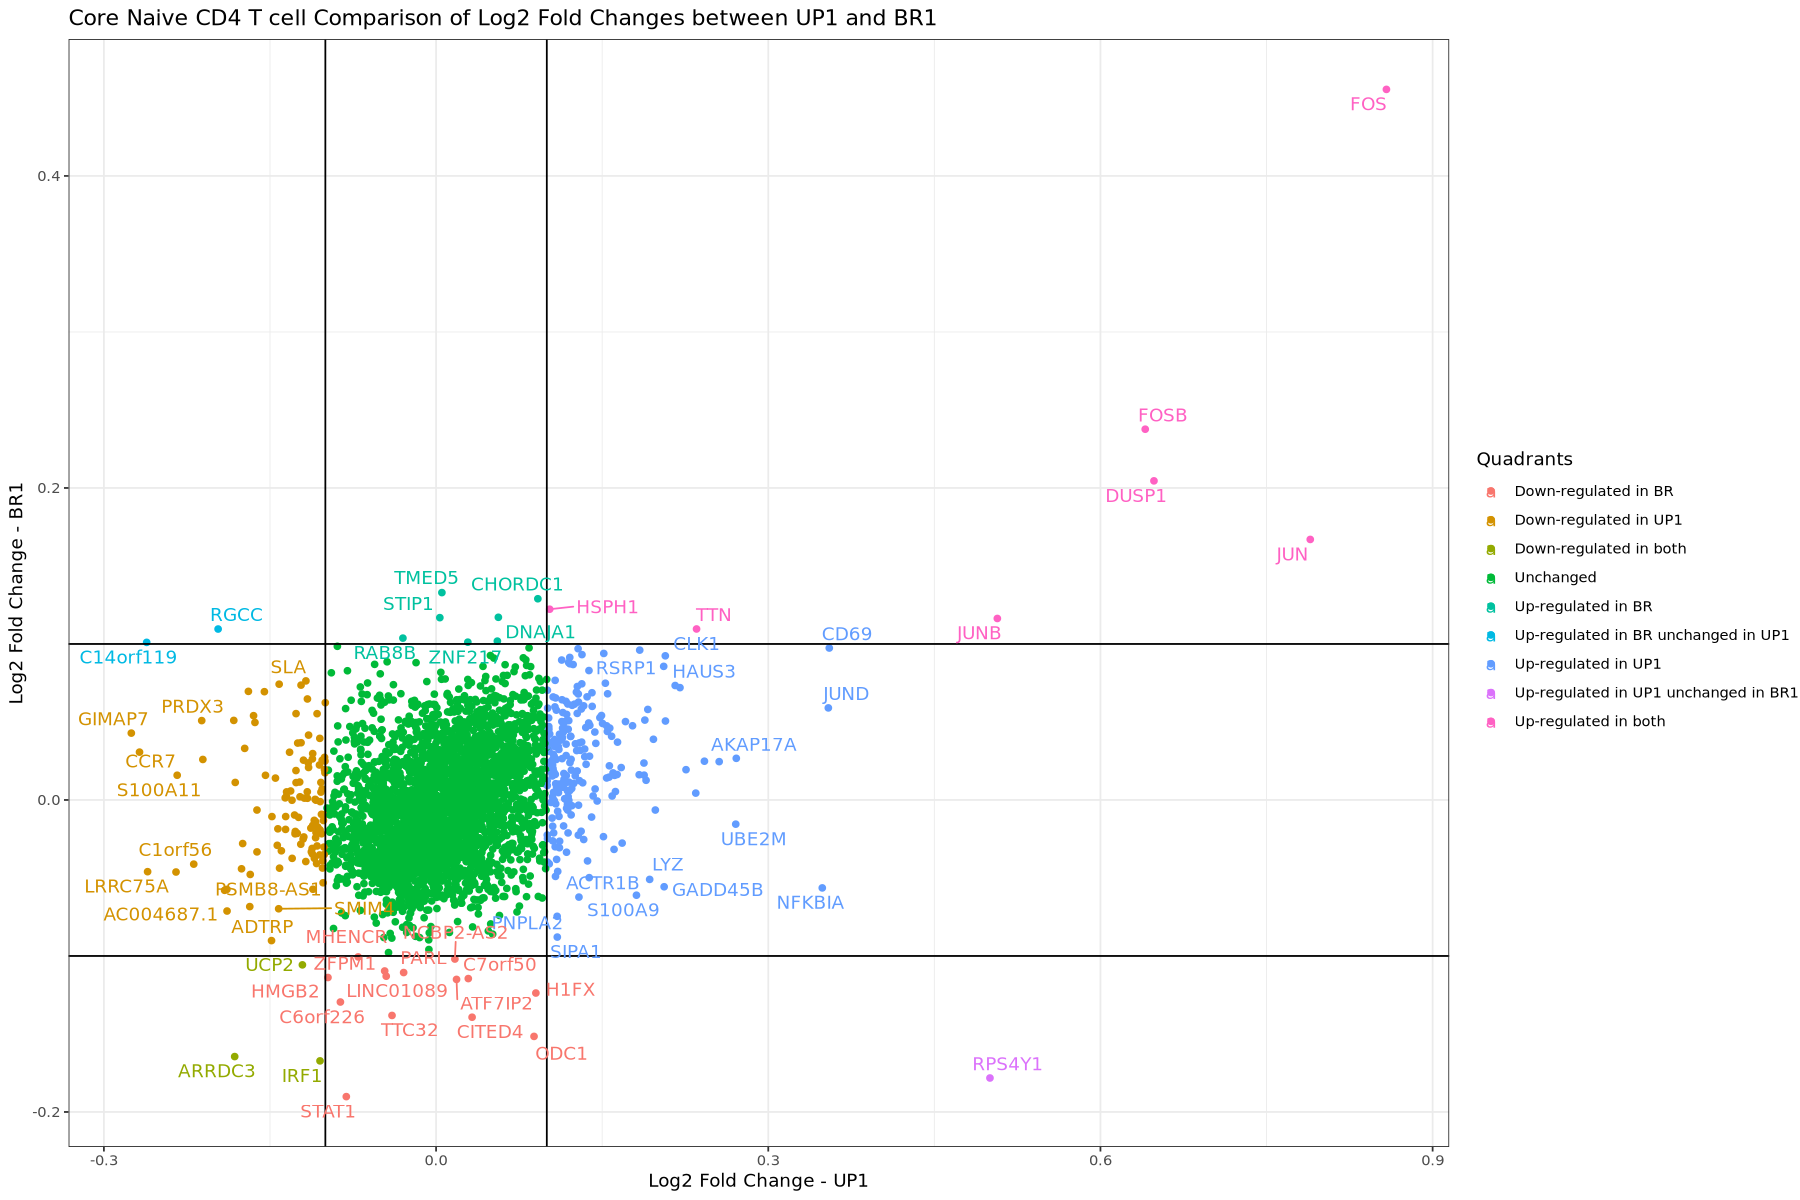

In [36]:
options(repr.plot.width = 15, repr.plot.height = 10)
# Create the scatter plot
scatter <- ggplot(merged_df, aes(x = log2FoldChange.x, y = log2FoldChange.y, color = Quadrants)) +
  geom_point() +
  geom_vline(xintercept = c(-0.1, 0.1)) +
  geom_hline(yintercept = c(-0.1, 0.1)) +
  theme_minimal() +
  xlab("Log2 Fold Change - UP1") +
  ylab("Log2 Fold Change - BR1") +
  
  # Add labels, ensuring no duplicates
  geom_text_repel(data = subset(merged_df, Expression.x != "Unchanged" | Expression.y != "Unchanged"),
                  aes(label = gene),
                  max.overlaps = 10) +
  
  theme_bw() +
  ggtitle("Core Naive CD4 T cell Comparison of Log2 Fold Changes between UP1 and BR1")

# Display the plot
print(scatter)
#ggsave('comparison_scatterplots/UP1_BR_KLRF1neg_GZMBpos_CD27neg_EM_CD8_Tcell_05.png',scatter, width = 15, height = 10, dpi = 300)

Warning message:
“Removed 398 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 398 rows containing missing values or values outside the scale range
(`geom_point()`).”


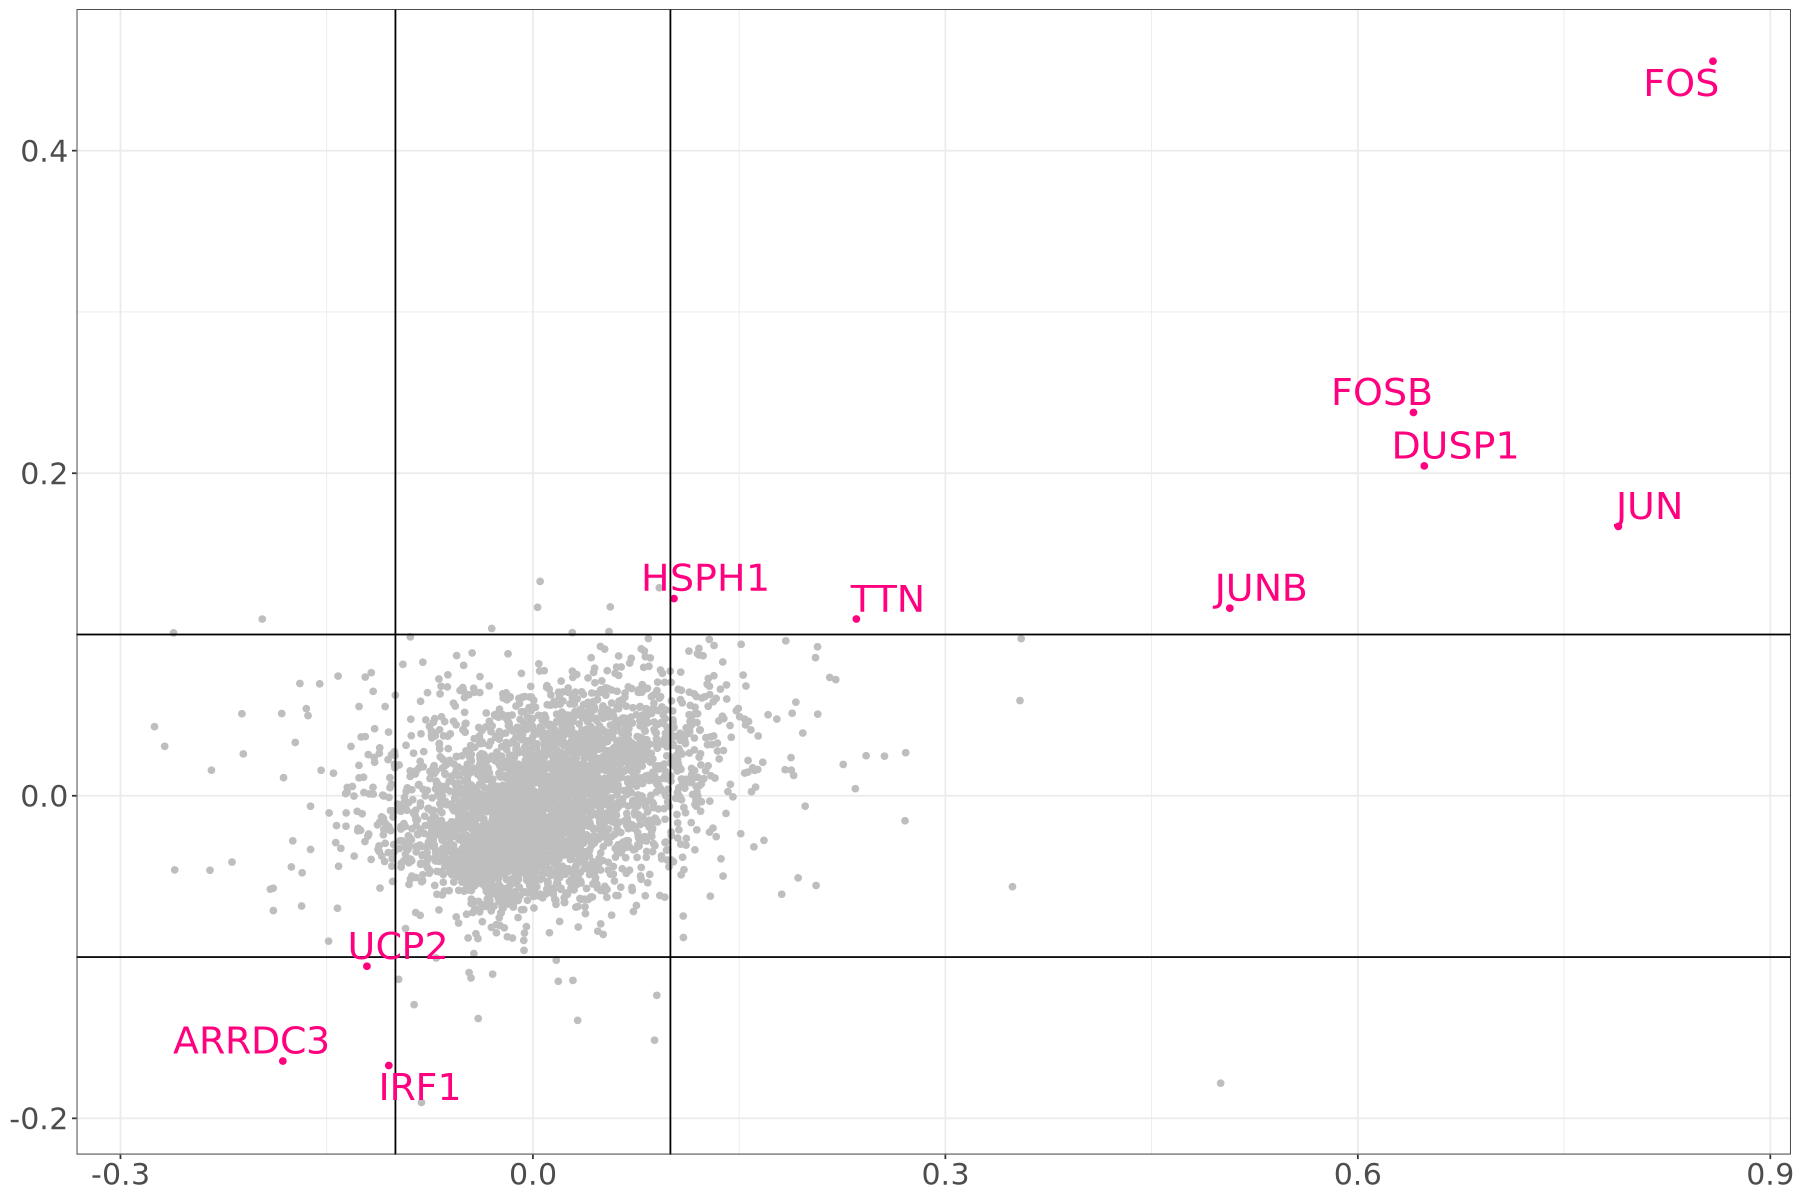

In [27]:
options(repr.plot.width = 15, repr.plot.height = 10)
scatter <- ggplot(merged_df, aes(x = log2FoldChange.x, y = log2FoldChange.y, color = Quadrants)) +
  geom_point() +
  geom_vline(xintercept = c(-0.1, 0.1)) +
  geom_hline(yintercept = c(-0.1, 0.1)) +
  geom_text_repel(data = subset(merged_df, Quadrants != "Unchanged" ),
                  aes(label = gene),
                  size=8,
                  max.overlaps =18) +
  scale_color_manual(values = c(
    "Up-regulated in both" = "#ff007f", 
    "Down-regulated in both" = "#ff007f", 
    "Unchanged" = "gray"
  )) +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(size=18),
    axis.title.y = element_blank(),
    axis.text.y = element_text(size=18),
    legend.position = "none"  # removes legend completely
  )


# Display the plot
print(scatter)
ggsave('/home/workspace/pediatric_IH/jupyter/Analysis/AAI_plots/similar_up1_br1_AAI.png',scatter, width = 15, height = 10, dpi = 300)
#ggsave('comparison_scatterplot_10-02-2025/UP1_BR1_core_naive_cd4_Tcell_UP1-05.png',scatter, width = 15, height = 10, dpi = 300)

### Comapring Naive Cells

In [28]:
cd4_up1 <- up1 %>% filter(up1$celltype == 'Core naive CD4 T cell')
cd8_up1 <- up1 %>% filter(up1$celltype == 'Core naive CD8 T cell')

In [29]:
cd4_up1 <- cd4_up1 %>% filter(cd4_up1$contrast == 'sample.visitName')
cd8_up1 <- cd8_up1 %>% filter(cd8_up1$contrast == 'sample.visitName')

In [30]:
cd4_up1 <- cd4_up1 %>% mutate(Expression = case_when(
    log2FoldChange >= 0.1  ~ "Up-regulated",
    log2FoldChange <= -0.1  ~ "Down-regulated",
    TRUE ~ "Unchanged"
      
  ))

cd8_up1 <- cd8_up1 %>% mutate(Expression = case_when(
    log2FoldChange >= 0.1  ~ "Up-regulated",
    log2FoldChange <= -0.1 ~ "Down-regulated",
    TRUE ~ "Unchanged"
      
  ))

In [31]:
merged_df <- full_join(cd4_up1, cd8_up1, by='gene')

In [10]:
#filtering for quadrant areas
merged_df <- merged_df %>% mutate(Quadrants = case_when(
    log2FoldChange.x >= 0.1 & log2FoldChange.y >=0.1 ~ "Up-regulated in both",
    log2FoldChange.x <= -0.1 & log2FoldChange.y <=-0.1 ~ "Down-regulated in both",
    (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y >=0.1 ~ "Up-regulated in CD8 ",
    (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y >=0.1 | log2FoldChange.x <= -0.1  & log2FoldChange.y >=0.1~ "Up-regulated in CD8 unchanged in CD4",
    (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y <=-0.1 ~ "Down-regulated in CD8",
     log2FoldChange.x <= -0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1)~ "Down-regulated in CD4",
    log2FoldChange.x >= 0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1) ~ "Up-regulated in CD4",
    log2FoldChange.x >= 0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1) | log2FoldChange.x >= 0.1  & log2FoldChange.y <=0.1 ~ "Up-regulated in CD4 unchanged in CD8",
    TRUE ~ 'Unchanged'
  ))

In [32]:
#filtering for quadrant areas
merged_df <- merged_df %>% mutate(Quadrants = case_when(
    log2FoldChange.x >= 0.1 & log2FoldChange.y >=0.1 ~ "Up-regulated in both",
    log2FoldChange.x <= -0.1 & log2FoldChange.y <=-0.1 ~ "Down-regulated in both",
    # (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y >=0.1 ~ "Up-regulated in CD8 ",
    # (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y >=0.1 | log2FoldChange.x <= -0.1  & log2FoldChange.y >=0.1~ "Up-regulated in CD8 unchanged in CD4",
    # (log2FoldChange.x >= -0.1 &log2FoldChange.x <= 0.1) & log2FoldChange.y <=-0.1 ~ "Down-regulated in CD8",
    #  log2FoldChange.x <= -0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1)~ "Down-regulated in CD4",
    # log2FoldChange.x >= 0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1) ~ "Up-regulated in CD4",
    # log2FoldChange.x >= 0.1  & (log2FoldChange.y <=0.1 & log2FoldChange.y >=-0.1) | log2FoldChange.x >= 0.1  & log2FoldChange.y <=0.1 ~ "Up-regulated in CD4 unchanged in CD8",
    TRUE ~ 'Unchanged'
  ))

Warning message:
“Removed 478 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 76 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 467 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“Removed 478 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 76 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 462 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


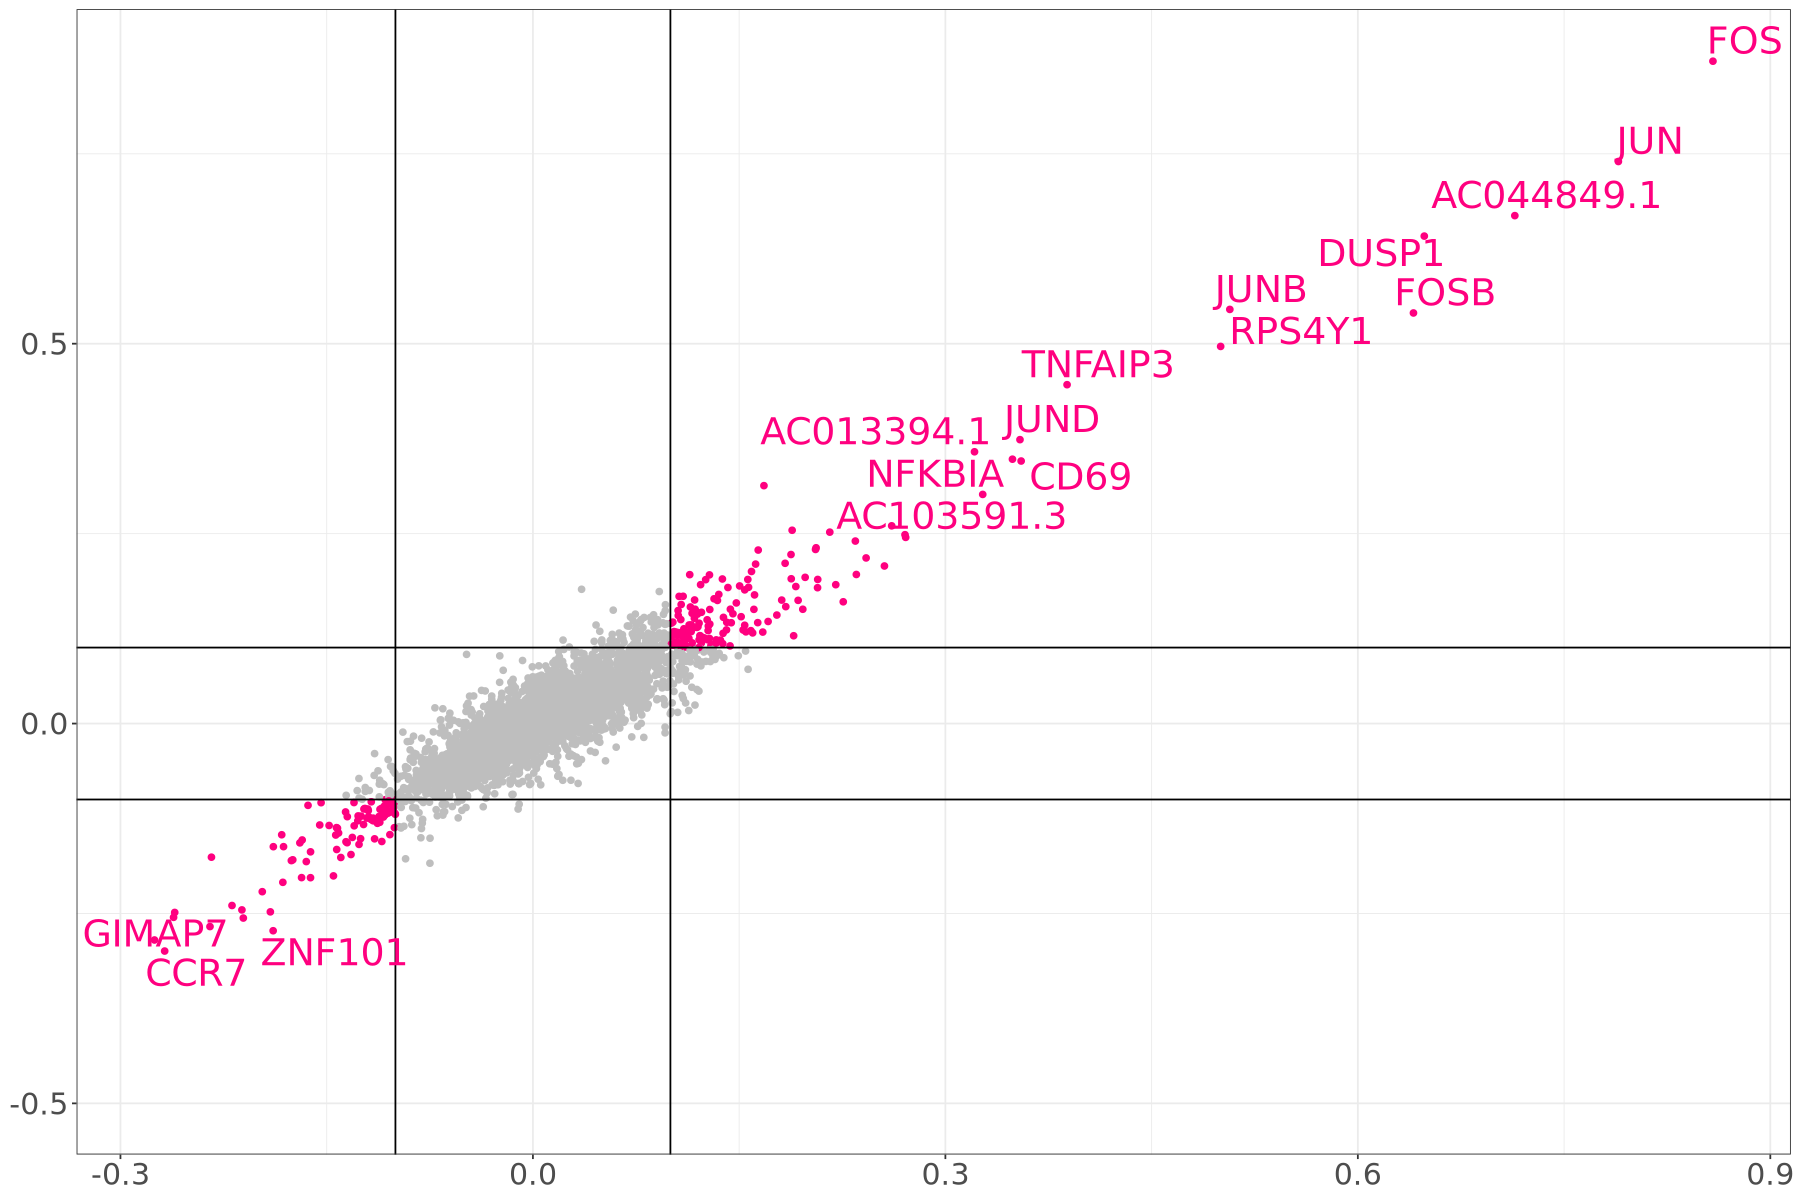

In [34]:

options(repr.plot.width = 15, repr.plot.height = 10)

scatter <- ggplot(merged_df, aes(x = log2FoldChange.x, y = log2FoldChange.y, color = Quadrants)) +
  geom_point() +
  geom_vline(xintercept = c(-0.1, 0.1)) +
  geom_hline(yintercept = c(-0.1, 0.1)) +
  geom_text_repel(data = subset(merged_df, Expression.x != "Unchanged" | Expression.y != "Unchanged"),
                  aes(label = gene),
                  size = 8,
                  max.overlaps = 15) +
  scale_color_manual(values = c(
    "Up-regulated in both" = "#ff007f", 
    "Down-regulated in both" = "#ff007f", 
    "Unchanged" = "gray"
  )) +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(size = 18),
    axis.title.y = element_blank(),
    axis.text.y = element_text(size = 18),
    legend.position = "none"  # removes legend completely
  )

print(scatter)
ggsave('/home/workspace/pediatric_IH/jupyter/Analysis/AAI_plots/cd4_cd8_comaprison.png',scatter, width = 15, height = 10, dpi = 300)